In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import cv2
from PIL import Image

import tensorflow as tf
tf.random.set_seed(42)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.math import confusion_matrix

from sklearn.metrics import classification_report

try:
    from google.colab.patches import cv2_imshow
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')
print(f'Running in Colab: {IN_COLAB}')

All libraries imported successfully!
TensorFlow version: 2.20.0
Running in Colab: True


In [2]:
# Loading the MNIST data from keras.datasets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('Dataset loaded successfully!')
print(f'\nTraining data:   {X_train.shape}  → {X_train.shape[0]} images of {X_train.shape[1]}×{X_train.shape[2]}')
print(f'Training labels: {Y_train.shape}')
print(f'\nTest data:       {X_test.shape}  → {X_test.shape[0]} images of {X_test.shape[1]}×{X_test.shape[2]}')
print(f'Test labels:     {Y_test.shape}')

print(f'\nUnique labels in train: {np.unique(Y_train)}')
print(f'Pixel value range: {X_train.min()} to {X_train.max()}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset loaded successfully!

Training data:   (60000, 28, 28)  → 60000 images of 28×28
Training labels: (60000,)

Test data:       (10000, 28, 28)  → 10000 images of 28×28
Test labels:     (10000,)

Unique labels in train: [0 1 2 3 4 5 6 7 8 9]
Pixel value range: 0 to 255


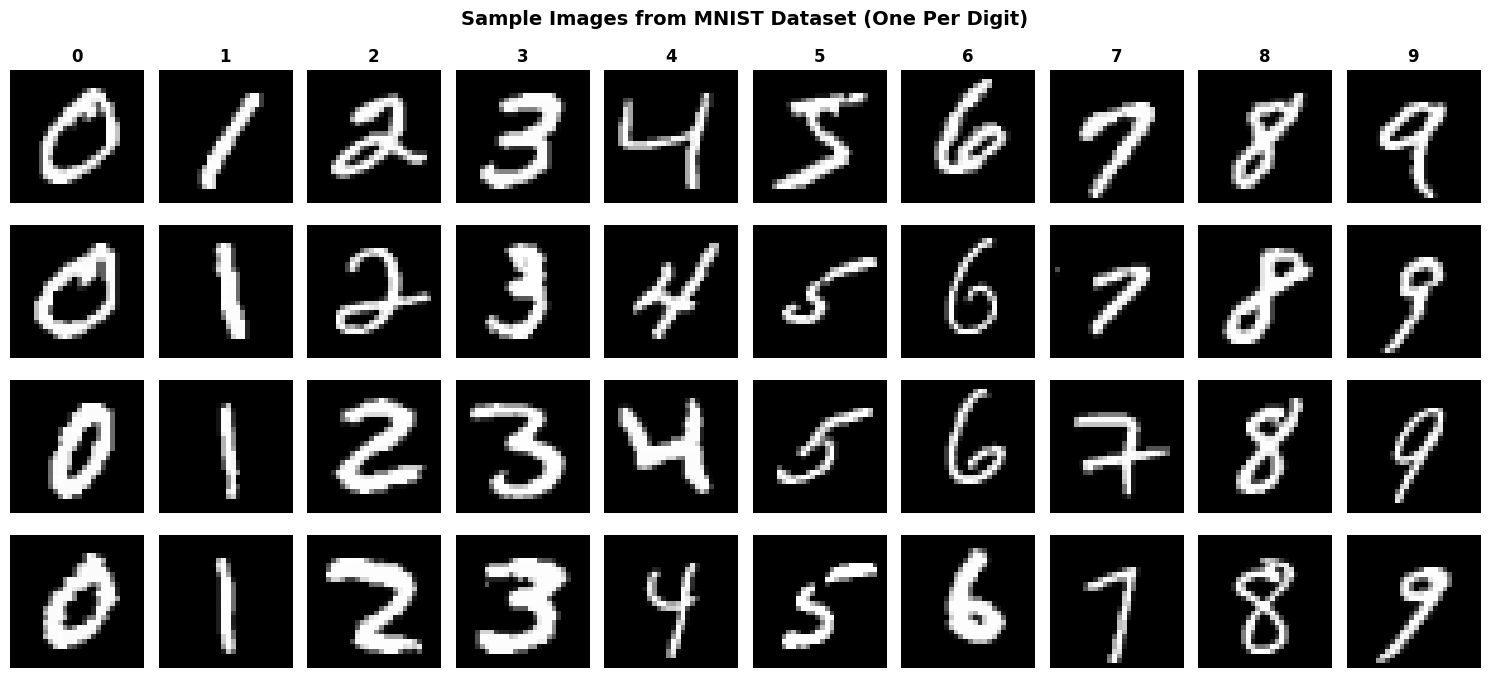

In [3]:
# Display sample images from the dataset
fig, axes = plt.subplots(4, 10, figsize=(15, 7))
fig.suptitle('Sample Images from MNIST Dataset (One Per Digit)', fontsize=14, fontweight='bold')

for digit in range(10):
# Find indices for this digit
    digit_indices = np.where(Y_train == digit)[0][:4]
    for row, idx in enumerate(digit_indices):
        axes[row][digit].imshow(X_train[idx], cmap='gray')
        axes[row][digit].axis('off')
        if row == 0:
            axes[row][digit].set_title(str(digit), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

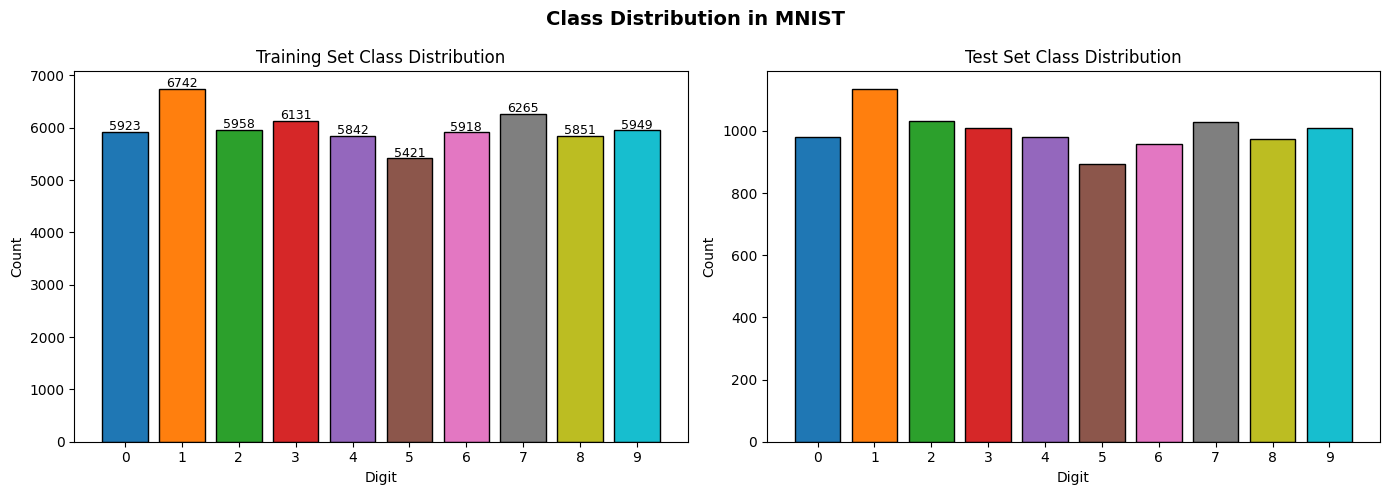

 The dataset is well-balanced — each digit has roughly equal representation!


In [5]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution in MNIST', fontsize=14, fontweight='bold')

# Training set
unique_train, counts_train = np.unique(Y_train, return_counts=True)
axes[0].bar(unique_train, counts_train, color=plt.cm.tab10(np.linspace(0, 1, 10)),
            edgecolor='black')
axes[0].set_title('Training Set Class Distribution')
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(10))
for i, (d, c) in enumerate(zip(unique_train, counts_train)):
    axes[0].text(d, c + 30, str(c), ha='center', fontsize=9)

# Test set
unique_test, counts_test = np.unique(Y_test, return_counts=True)
axes[1].bar(unique_test, counts_test, color=plt.cm.tab10(np.linspace(0, 1, 10)),
            edgecolor='black')
axes[1].set_title('Test Set Class Distribution')
axes[1].set_xlabel('Digit')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(10))

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' The dataset is well-balanced — each digit has roughly equal representation!')

Sample image (digit at index 10):
Label: 3
Image shape: (28, 28)
Pixel values (raw):
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0 

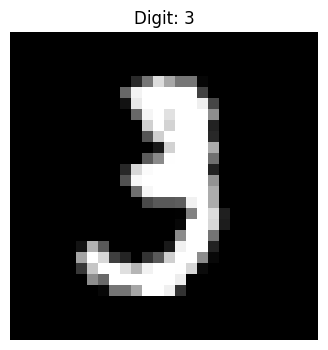

In [6]:
# Show pixel value distribution before and after normalization
print('Sample image (digit at index 10):')
print('Label:', Y_train[10])
print('Image shape:', X_train[10].shape)
print('Pixel values (raw):'); print(X_train[10])

plt.figure(figsize=(4, 4))
plt.imshow(X_train[10], cmap='gray')
plt.title(f'Digit: {Y_train[10]}')
plt.axis('off')
plt.show()

In [7]:
# Normalizing pixel values from 0-255 to 0-1
X_train_scaled = X_train / 255.0
X_test_scaled  = X_test  / 255.0

print('After normalization:')
print(f'  Min pixel value: {X_train_scaled.min()}')
print(f'  Max pixel value: {X_train_scaled.max()}')

# Reshaping for CNN: (samples, 28, 28, 1)
# The extra dimension (1) represents the grayscale channel
X_train_cnn = X_train_scaled.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test_scaled.reshape(-1, 28, 28, 1)

print(f'\nReshape for CNN:')
print(f'  X_train shape: {X_train_cnn.shape}  (samples, height, width, channels)')
print(f'  X_test shape:  {X_test_cnn.shape}')
print('\n Preprocessing complete!')

After normalization:
  Min pixel value: 0.0
  Max pixel value: 1.0

Reshape for CNN:
  X_train shape: (60000, 28, 28, 1)  (samples, height, width, channels)
  X_test shape:  (10000, 28, 28, 1)

 Preprocessing complete!


In [8]:
# Building the CNN model
model = keras.Sequential([

    # ---- First Convolutional Block ----
    # 32 filters, 3x3 kernel — detects basic features like edges
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1),
                  padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),      # Reduce 28x28 → 14x14
    layers.Dropout(0.25),

    # ---- Second Convolutional Block ----
    # 64 filters — detects more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),      # Reduce 14x14 → 7x7
    layers.Dropout(0.25),

    # ---- Flatten and Fully Connected Layers ----
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # ---- Output Layer ----
    # 10 neurons (one per digit), softmax for multi-class
    layers.Dense(10, activation='softmax')
])

# Compiling the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,538 (1.61 MB)

 Trainable params: 422,090 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

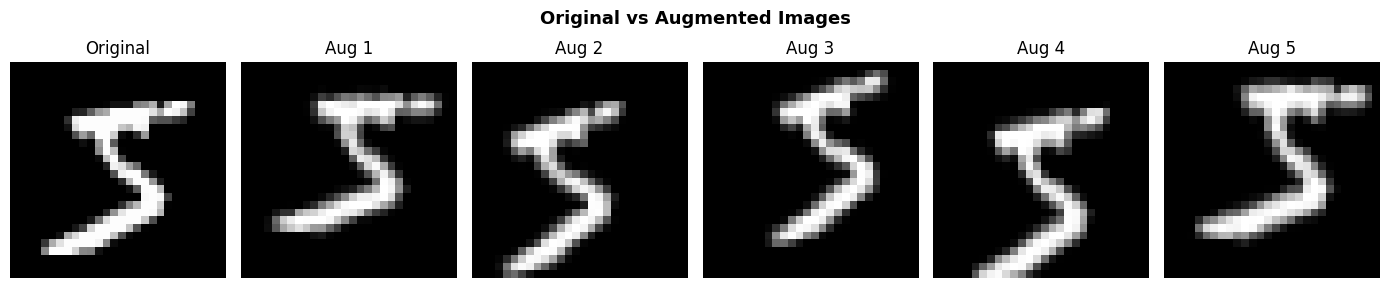

 Same digit — slightly different each time. This helps the model generalize better!


In [10]:
# Data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=10,      # Randomly rotate images up to 10 degrees
    zoom_range=0.10,        # Randomly zoom in/out by up to 10%
    width_shift_range=0.10, # Randomly shift horizontally by up to 10%
    height_shift_range=0.10 # Randomly shift vertically by up to 10%
)

datagen.fit(X_train_cnn)

# Visualize augmented samples
sample_img = X_train_cnn[0:1]
aug_iter = datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
fig.suptitle('Original vs Augmented Images', fontsize=13, fontweight='bold')
axes[0].imshow(sample_img[0].reshape(28, 28), cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
for i in range(1, 6):
    aug_img = next(aug_iter)[0]
    axes[i].imshow(aug_img.reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Same digit — slightly different each time. This helps the model generalize better!')

In [11]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Training with augmented data
print('Training the CNN model with data augmentation...')
history = model.fit(
    datagen.flow(X_train_cnn, Y_train, batch_size=64),
    epochs=20,
    validation_data=(X_test_cnn, Y_test),
    callbacks=callbacks,
    verbose=1
)

print(f'\n Training complete! Stopped at epoch {len(history.history["accuracy"])}')

Training the CNN model with data augmentation...
Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 200s 208ms/step - accuracy: 0.8831 - loss: 0.3753 - val_accuracy: 0.9844 - val_loss: 0.0492 - learning_rate: 0.0010
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 156s 166ms/step - accuracy: 0.9528 - loss: 0.1535 - val_accuracy: 0.9882 - val_loss: 0.0365 - learning_rate: 0.0010
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 156s 166ms/step - accuracy: 0.9621 - loss: 0.1213 - val_accuracy: 0.9884 - val_loss: 0.0354 - learning_rate: 0.0010
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 155s 165ms/step - accuracy: 0.9666 - loss: 0.1107 - val_accuracy: 0.9771 - val_loss: 0.0759 - learning_rate: 0.0010
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 154s 164ms/step - accuracy: 0.9708 - loss: 0.0956 - val_accuracy: 0.9918 - val_loss: 0.0255 - learning_rate: 0.0010
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 156s 166ms/step - accuracy: 0.9726 - loss: 0.0899 - val_accuracy: 0.9926 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 7/20
938/

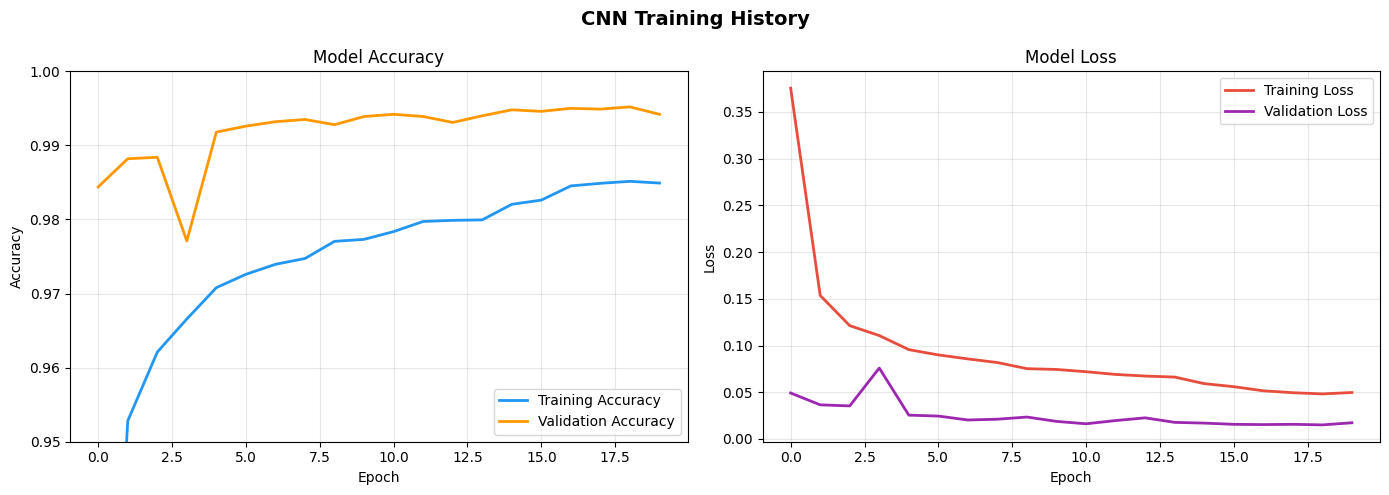

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training History', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Training Accuracy',   color='#2196F3', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#FF9800', lw=2)
axes[0].set_title('Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.95, 1.0])

# Loss
axes[1].plot(history.history['loss'],     label='Training Loss',   color='#e74c3c', lw=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#9C27B0', lw=2)
axes[1].set_title('Model Loss')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Final test accuracy
loss, accuracy = model.evaluate(X_test_cnn, Y_test, verbose=0)
print('='*45)
print('FINAL TEST RESULTS')
print('='*45)
print(f'Test Loss:     {loss:.4f}')
print(f'Test Accuracy: {accuracy*100:.2f}%')
print(f'Error Rate:    {(1-accuracy)*100:.2f}%')

FINAL TEST RESULTS
Test Loss:     0.0151
Test Accuracy: 99.52%
Error Rate:    0.48%


In [14]:
# Generate predictions
Y_pred       = model.predict(X_test_cnn, verbose=0)
Y_pred_labels = np.argmax(Y_pred, axis=1)

# Classification Report
print('PER-CLASS CLASSIFICATION REPORT:')
print(classification_report(Y_test, Y_pred_labels,
                             target_names=[str(i) for i in range(10)]))

PER-CLASS CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       1.00      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      1.00      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



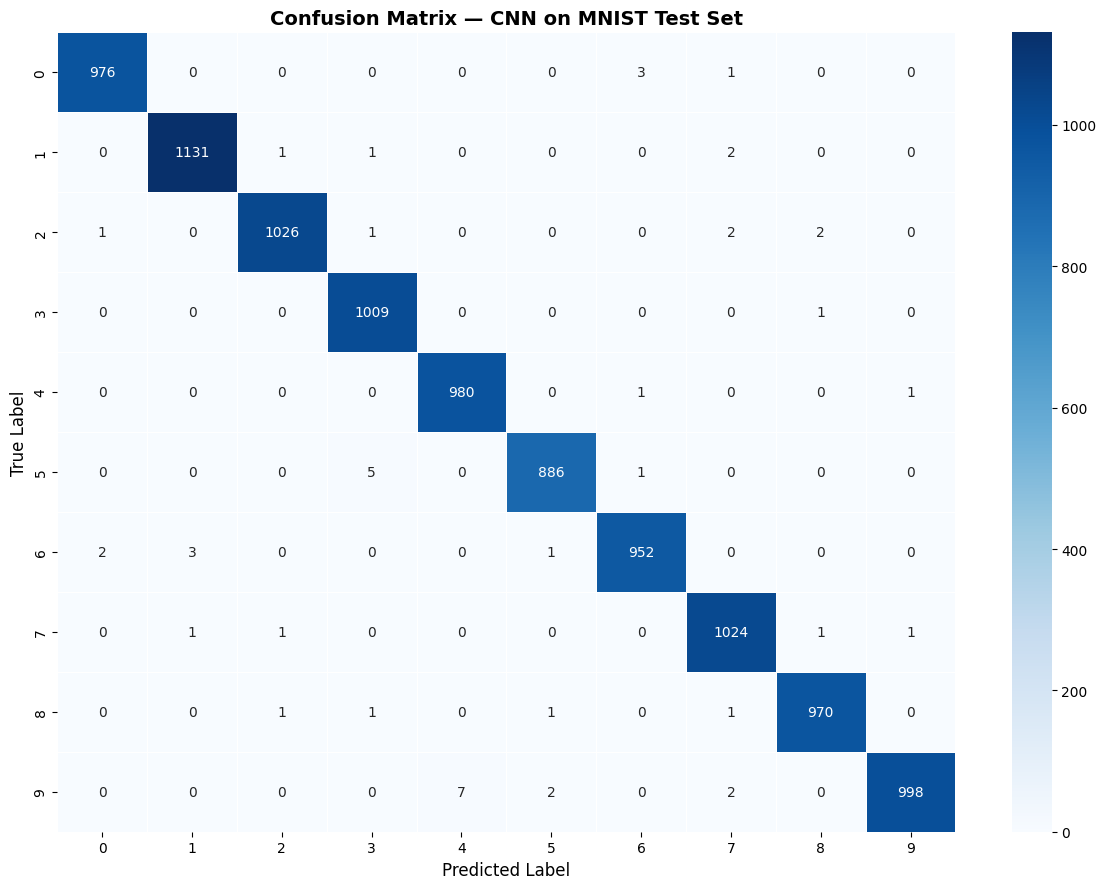


Correctly classified: 9952/10000 = 99.52%


In [15]:
# Confusion Matrix
conf_mat = confusion_matrix(Y_test, Y_pred_labels).numpy()

plt.figure(figsize=(12, 9))
sns.heatmap(
    conf_mat, annot=True, fmt='d', cmap='Blues',
    xticklabels=range(10), yticklabels=range(10),
    linewidths=0.5
)
plt.title('Confusion Matrix — CNN on MNIST Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

total_correct = np.diag(conf_mat).sum()
total = conf_mat.sum()
print(f'\nCorrectly classified: {total_correct}/{total} = {total_correct/total*100:.2f}%')

Total misclassified: 48 out of 10000
Accuracy: 99.52%


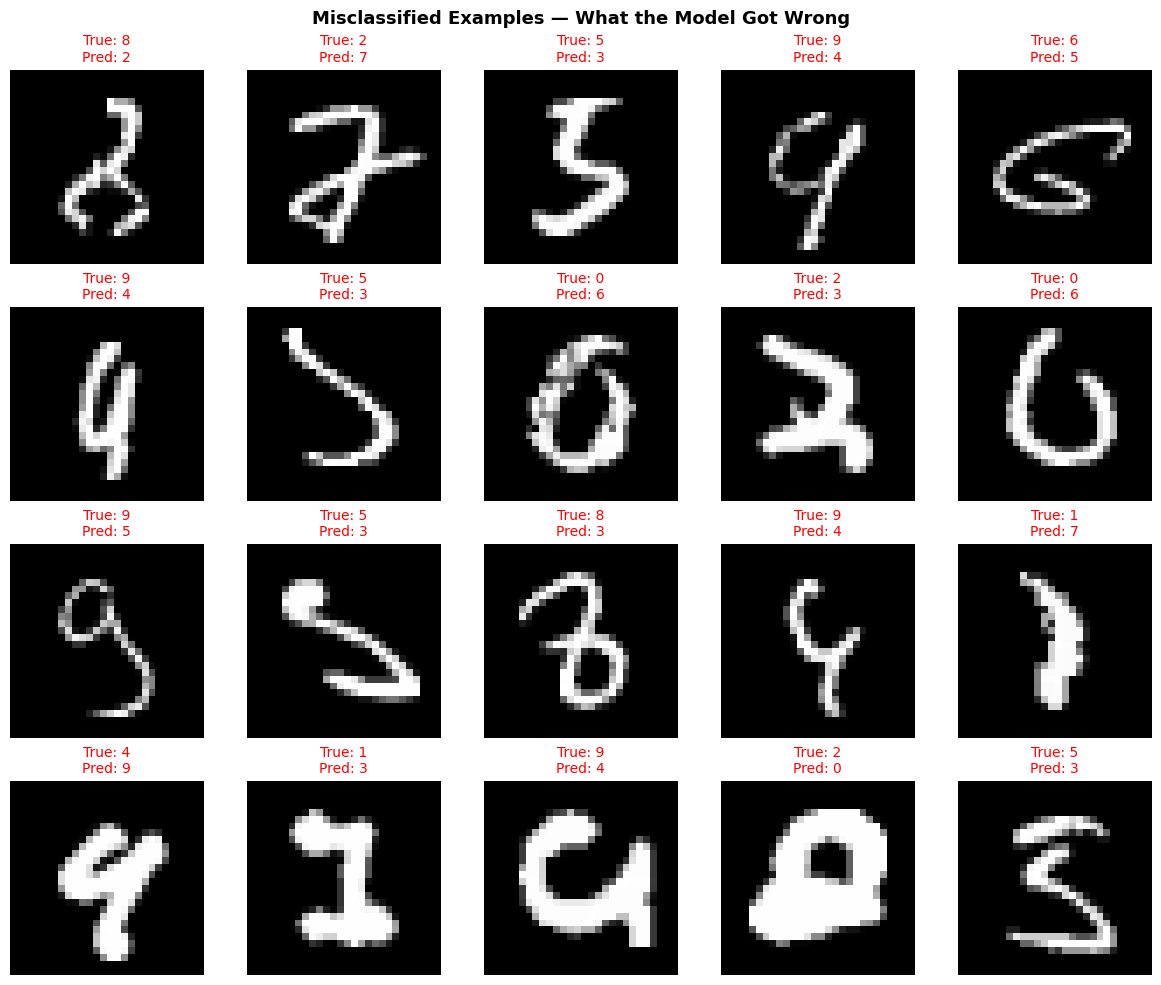

📊 Even humans sometimes struggle to read these ambiguous handwritten digits!


In [16]:
# Find all misclassified examples
wrong_indices = np.where(Y_pred_labels != Y_test)[0]
print(f'Total misclassified: {len(wrong_indices)} out of {len(Y_test)}')
print(f'Accuracy: {(1 - len(wrong_indices)/len(Y_test))*100:.2f}%')

# Show first 20 misclassified examples
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle('Misclassified Examples — What the Model Got Wrong', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, idx in enumerate(wrong_indices[:20]):
    axes[i].imshow(X_test[idx], cmap='gray')
    axes[i].set_title(
        f'True: {Y_test[idx]}\nPred: {Y_pred_labels[idx]}',
        color='red', fontsize=10
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('misclassified_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Even humans sometimes struggle to read these ambiguous handwritten digits!')

In [17]:
# Which digits are hardest to classify?
errors_per_digit = {}
for digit in range(10):
    digit_mask = (Y_test == digit)
    digit_total = digit_mask.sum()
    digit_wrong = ((Y_pred_labels != Y_test) & digit_mask).sum()
    errors_per_digit[digit] = {
        'Total': int(digit_total),
        'Wrong': int(digit_wrong),
        'Error Rate (%)': round(digit_wrong/digit_total*100, 2)
    }

import pandas as pd
error_df = pd.DataFrame(errors_per_digit).T.sort_values('Error Rate (%)', ascending=False)
print('Error Rate Per Digit:')
print(error_df.to_string())
print('\n(Higher error rate = harder digit to classify)')

Error Rate Per Digit:
    Total  Wrong  Error Rate (%)
9  1009.0   11.0            1.09
5   892.0    6.0            0.67
6   958.0    6.0            0.63
2  1032.0    6.0            0.58
8   974.0    4.0            0.41
0   980.0    4.0            0.41
7  1028.0    4.0            0.39
1  1135.0    4.0            0.35
4   982.0    2.0            0.20
3  1010.0    1.0            0.10

(Higher error rate = harder digit to classify)


--- Predicting from test dataset ---


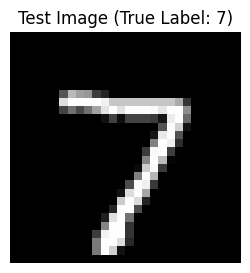

True Label:        7
Predicted Digit:   7
Confidence:        100.00%


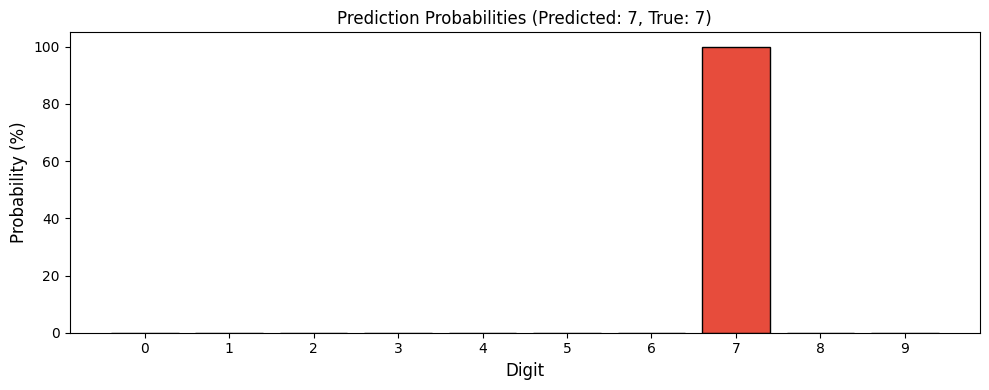

In [18]:
# Method 1: Predict from test dataset (same as original notebook)
print('--- Predicting from test dataset ---')

# Show first test image
plt.figure(figsize=(3, 3))
plt.imshow(X_test[0], cmap='gray')
plt.title(f'Test Image (True Label: {Y_test[0]})')
plt.axis('off')
plt.show()

# Get prediction
prediction_probs = model.predict(X_test_cnn[0:1], verbose=0)[0]
predicted_digit  = np.argmax(prediction_probs)
confidence       = prediction_probs[predicted_digit] * 100

print(f'True Label:        {Y_test[0]}')
print(f'Predicted Digit:   {predicted_digit}')
print(f'Confidence:        {confidence:.2f}%')

# Show full probability distribution
plt.figure(figsize=(10, 4))
colors = ['#e74c3c' if i == predicted_digit else '#2196F3' for i in range(10)]
plt.bar(range(10), prediction_probs * 100, color=colors, edgecolor='black')
plt.xlabel('Digit', fontsize=12)
plt.ylabel('Probability (%)', fontsize=12)
plt.title(f'Prediction Probabilities (Predicted: {predicted_digit}, True: {Y_test[0]})', fontsize=12)
plt.xticks(range(10))
plt.tight_layout()
plt.show()

In [19]:
# Method 2: Predict from an uploaded image file
# Upload the 3-digit.PNG file (or any digit image) to Colab first

def predict_digit_from_image(image_path):
    """
    Predicts the handwritten digit in the given image file.
    Supports any image format: PNG, JPG, etc.
    """
    try:
        # Read and process the image
        input_image = cv2.imread(image_path)

        if input_image is None:
            print(f'Error: Could not read image at {image_path}')
            return None

        # Display original image
        print('Input Image:')
        if IN_COLAB:
            from google.colab.patches import cv2_imshow
            cv2_imshow(input_image)
        else:
            plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.show()

        # Convert to grayscale
        grayscale = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

        # Resize to 28x28 (MNIST standard)
        resized = cv2.resize(grayscale, (28, 28))

        # Normalize
        normalized = resized / 255.0

        # Reshape for CNN: (1, 28, 28, 1)
        reshaped = normalized.reshape(1, 28, 28, 1)

        # Predict
        probs   = model.predict(reshaped, verbose=0)[0]
        digit   = np.argmax(probs)
        conf    = probs[digit] * 100

        print(f'\n🔢 Predicted Digit: {digit}')
        print(f'   Confidence:      {conf:.2f}%')
        return digit

    except Exception as e:
        print(f'Error: {e}')
        return None


# Run prediction on the provided 3-digit.PNG
predict_digit_from_image('/content/3-digit.PNG')

Error: Could not read image at /content/3-digit.PNG


=== INTERACTIVE PREDICTIVE SYSTEM ===
Enter the path of the digit image to predict: 3-digit.PNG
Input Image:


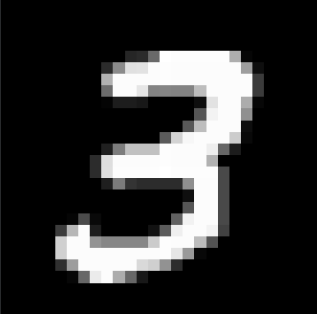


🔢 Predicted Digit: 3
   Confidence:      100.00%


np.int64(3)

In [20]:
# Fully interactive predictive system (original notebook version — enhanced)
print('=== INTERACTIVE PREDICTIVE SYSTEM ===')
image_path = input('Enter the path of the digit image to predict: ')
predict_digit_from_image(image_path)

In [21]:
# Save the trained CNN model
model.save('mnist_cnn_model.h5')
print('CNN model saved as mnist_cnn_model.h5')

print('\nTo load and use later:')
print('  model = keras.models.load_model("mnist_cnn_model.h5")')
print('  prediction = model.predict(your_image.reshape(1, 28, 28, 1))')
print('  digit = np.argmax(prediction)')

CNN model saved as mnist_cnn_model.h5

To load and use later:
  model = keras.models.load_model("mnist_cnn_model.h5")
  prediction = model.predict(your_image.reshape(1, 28, 28, 1))
  digit = np.argmax(prediction)
